# Ensemble Methods

In [2]:
import pandas as pd

#### Import preprocessed data

In [3]:
PROCESSED_DATA_PATH = 'data/processed'

# 1 - non-scaled

X_train_non_scaled  = pd.read_csv(f'{PROCESSED_DATA_PATH}/X_train_non_scaled.csv')
X_val_non_scaled    = pd.read_csv(f'{PROCESSED_DATA_PATH}/X_val_non_scaled.csv')
X_test_non_scaled   = pd.read_csv(f'{PROCESSED_DATA_PATH}/X_test_non_scaled.csv')

# 2 - robust scaled

X_train_scaled_robust = pd.read_csv(f'{PROCESSED_DATA_PATH}/X_train_robust_scaled.csv')
X_val_scaled_robust   = pd.read_csv(f'{PROCESSED_DATA_PATH}/X_val_robust_scaled.csv')
X_test_scaled_robust  = pd.read_csv(f'{PROCESSED_DATA_PATH}/X_test_robust_scaled.csv')

# 3 - min-max scaled

X_train_scaled_minmax = pd.read_csv(f'{PROCESSED_DATA_PATH}/X_train_minmax_scaled.csv')
X_val_scaled_minmax   = pd.read_csv(f'{PROCESSED_DATA_PATH}/X_val_minmax_scaled.csv')
X_test_scaled_minmax  = pd.read_csv(f'{PROCESSED_DATA_PATH}/X_test_minmax_scaled.csv')

# 4 - standard scaled
X_train_scaled_standard = pd.read_csv(f'{PROCESSED_DATA_PATH}/X_train_standard_scaled.csv')
X_val_scaled_standard   = pd.read_csv(f'{PROCESSED_DATA_PATH}/X_val_standard_scaled.csv')
X_test_scaled_standard  = pd.read_csv(f'{PROCESSED_DATA_PATH}/X_test_standard_scaled.csv')

# y
y_train = pd.read_csv(f'{PROCESSED_DATA_PATH}/y_train.csv')
y_val   = pd.read_csv(f'{PROCESSED_DATA_PATH}/y_val.csv')


X_train_full = pd.concat([X_train_non_scaled, X_val_non_scaled])
y_train_full = pd.concat([y_train, y_val])

print("\nAll versions loaded.")


All versions loaded.


In [18]:
'''
training.py
'''
import json
from datetime import datetime
import os
import shutil

import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score, precision_score, recall_score
from sklearn.pipeline import make_pipeline
from sklearn.utils.parallel import Parallel, delayed
import joblib
import wandb
import matplotlib.pyplot as plt


def refit_full(model, X_full: pd.DataFrame, y_full: pd.Series) -> None:
    """Refit best model on train+val combined before submission."""

    print("Refitting best model on full training data (train + val)...")
    model.fit(X_full, y_full)


def compute_metrics(y_real: pd.Series, y_pred: pd.Series) -> list[float]:
    accuracy = accuracy_score(y_real,y_pred)
    f1_macro =f1_score(y_real,y_pred, average='macro')
    precision_macro =precision_score(y_real,y_pred,  average='macro')
    recall_macro =recall_score(y_real,y_pred,  average='macro')
    classif_report = classification_report(y_real, y_pred)
    return [accuracy, f1_macro, precision_macro, recall_macro, classif_report]


def evaluate(base_name: str, model, X_val: pd.DataFrame, y_val: pd.Series,  best_params: dict|None = None) -> None:
    '''
    Evaluates the best model on the validation data and defines the experiment.
    '''
    print("Evaluating best model on unseen validation data...")

    y_pred = model.predict(X_val)

    define_experiment(base_name, compute_metrics(y_val, y_pred), y_val, y_pred)


import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from sklearn.metrics import confusion_matrix

def plot_spatial_confusion(y_true, y_pred, base_name="Model"):
    # 1. Define physical coordinates (radius, angle_in_degrees) based on your image
    polar_coords = {
        0: (2, 0),   1: (2, 45),  2: (2, 90),  3: (2, 135), 4: (2, 180),
        5: (5, 0),   6: (5, 45),  7: (5, 90),  8: (5, 135), 9: (5, 180)
    }

    # Convert polar to Cartesian (x, y) coordinates for plotting
    coords = {}
    for label, (r, theta) in polar_coords.items():
        rad = np.radians(theta)
        coords[label] = (r * np.cos(rad), r * np.sin(rad))

    # Calculate standard confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=range(10))

    fig, ax = plt.subplots(figsize=(12, 8))

    # 2. Draw the Tracking Unit (centered at origin, pointing outward)
    tracking_unit = patches.Rectangle((-1.5, -1.5), 3, 1.5, color='black', zorder=5)
    ax.add_patch(tracking_unit)
    ax.text(0, -0.75, 'Tracking\nunit', color='white', ha='center', va='center', weight='bold', zorder=6)

    # 3. Draw the background dashed guidelines
    for label in [5, 6, 7, 8, 9]:
        x, y = coords[label]
        ax.plot([0, x], [0, y], color='black', linestyle='--', alpha=0.6, zorder=1)

    # 4. Plot the position nodes (0 through 9)
    for label, (x, y) in coords.items():
        ax.plot(x, y, 'o', markersize=25, color='white', markeredgecolor='black', zorder=4)
        ax.text(x, y, str(label), ha='center', va='center', fontsize=12, zorder=5)

    # 5. Draw the confusion arrows
    # Find the maximum off-diagonal value so we can scale the arrow thickness
    off_diag_mask = ~np.eye(cm.shape[0], dtype=bool)
    max_conf = np.max(cm[off_diag_mask]) if np.any(cm[off_diag_mask]) else 1

    for i in range(10):
        for j in range(10):
            # Only plot off-diagonal elements (errors) where count > 0
            if i != j and cm[i, j] > 0:
                count = cm[i, j]
                x1, y1 = coords[i] # True position
                x2, y2 = coords[j] # Predicted position (where it was mistakenly placed)

                # Scale arrow thickness (linewidth) and opacity (alpha) based on error frequency
                lw = max(1, (count / max_conf) * 5)
                alpha = min(0.3 + (count / max_conf) * 0.7, 1.0)

                # Create a curved arrow so bidirectional confusions (i->j and j->i) don't overlap
                arrow = patches.FancyArrowPatch(
                    (x1, y1), (x2, y2),
                    connectionstyle="arc3,rad=0.15",
                    arrowstyle="->,head_length=8,head_width=4",
                    color='red',
                    linewidth=lw,
                    alpha=alpha,
                    shrinkA=15, # Leaves a gap so the arrow doesn't overlap the circle text
                    shrinkB=15,
                    zorder=3
                )
                ax.add_patch(arrow)

    # 6. Formatting to match the physical aspect ratio

    ax.set_aspect('equal')
    ax.set_xlim(-6, 6)
    ax.set_ylim(-2, 6)
    ax.axis('off')
    plt.title(f'Spatial Error Map: {base_name}', fontsize=16, pad=15)
    plt.tight_layout()

    return fig


def define_experiment(base_name: str, metrics: list[float], y_val: pd.Series, y_pred: pd.Series,  best_params: dict|None = None) -> None:

    accuracy, f1_macro, precision_macro, recall_macro, classif_report = metrics
    experiment_results = {
        "model_name": base_name,
        "best_hyperparameters": best_params,
        "validation_metrics": {"accuracy": accuracy, "f1_macro": f1_macro}
    }

    print("Initializing Weights & Biases run...")
    wandb.init(
        project="AA1",
        entity="laura-rebollo-crespo-universitat-polit-cnica-de-catalunya",
        name=f"{base_name}_f1-{f1_macro:.4f}",
        config={"model_name": base_name, "best_params": best_params})

    fig, ax = plt.subplots(figsize=(10, 8))

    disp = ConfusionMatrixDisplay.from_predictions(
        y_val,
        y_pred,
        ax=ax,
        cmap='viridis',
        colorbar=False
    )
    plt.title(f'Confusion Matrix: {base_name}', fontsize=16, pad=15)
    plt.tight_layout()
    spatial = plot_spatial_confusion(y_val, y_pred, base_name)

    # LOG IT TO W&B
    wandb.log({
        "val_accuracy": accuracy,
        "val_f1_macro": f1_macro,
        "val_precision_macro": precision_macro,
        "val_recall_macro": recall_macro,
        "classification_report": wandb.Html(f"<pre>{classif_report}</pre>"),

        "scikit_learn_matrix": wandb.Image(fig),
        "spatial_confusion_matrix": wandb.Image(spatial)
    })


    plt.close(fig)
    plt.close(spatial)


def save(base_name:str, model) -> None:
    """
    Saves the best model locally and uploads it to W&B as an artifact, then cleans up the local file.
    """
    models_dir = "outputs/models"
    os.makedirs(models_dir, exist_ok=True)

    # Save the Model locally first so W&B can grab it
    model_filepath = f"{models_dir}/{base_name}.pkl"
    print(f"Saving model locally to {model_filepath}...")
    joblib.dump(model, model_filepath)

    print("Uploading model to W&B Cloud...")
    model_artifact = wandb.Artifact(
        name=f"{base_name}_model",
        type="model",
        description="Trained  model"
    )
    model_artifact.add_file(model_filepath)
    wandb.log_artifact(model_artifact)

    if os.path.exists(model_filepath):
        os.remove(model_filepath)
        try:
            os.rmdir(models_dir)
        except OSError:
            pass  # Directory not empty or other error - that's fine
        print("Deleted:", model_filepath)
    else:
        print("File not found:", model_filepath)


def save_submission(y_pred: pd.Series, file_name: str) -> None:
    """
    Generates Kaggle predictions and uploads the CSV to W&B.
    """
    submissions_dir = "outputs/submissions"
    os.makedirs(submissions_dir, exist_ok=True)

    output_path = f"{submissions_dir}/{file_name}.csv"

    print("Generating Kaggle submission...")

    submission_ids = range(len(y_pred))

    submission = pd.DataFrame({
        "ID": submission_ids,
        "POSITION": y_pred.astype(int)
    })

    submission.to_csv(output_path, index=False)
    print(f"Submission saved locally to: {output_path}")

    # UPLOAD CSV TO W&B ---
    print("Uploading Kaggle submission to W&B Cloud...")
    csv_artifact = wandb.Artifact(
        name=f"{file_name}_submission",
        type="predictions"
    )
    csv_artifact.add_file(output_path)
    wandb.log_artifact(csv_artifact)

    wandb.finish()

#### Helper functions

In [4]:
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

### Downloading base models from W&B


In [5]:
import wandb
import joblib
import os
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import cross_val_score

y_val_1d = y_val.values.ravel()
y_train_1d = y_train.values.ravel()

# Initialize API
api = wandb.Api()
ENTITY_PROJECT = "laura-rebollo-crespo-universitat-polit-cnica-de-catalunya/AA1"

def load_wandb_model(model_name, version="latest"):
    """Downloads the .pkl artifact from W&B and loads it into memory."""
    print(f"Fetching {model_name} from W&B...")
    artifact = api.artifact(f"{ENTITY_PROJECT}/{model_name}_model:{version}")
    artifact_dir = artifact.download()
    
    for file in os.listdir(artifact_dir):
        if file.endswith(".pkl"):
            return joblib.load(os.path.join(artifact_dir, file))
    raise ValueError(f"No .pkl found in {model_name} artifact.")


print("Loading base models...")
mlp_model  = load_wandb_model("MLPClassifier")
svm_model  = load_wandb_model("SVC")
lgbm_model = load_wandb_model("LGBMClassifier")

xgboost_distance = load_wandb_model("XGBoost-GPU-DistanceAware", "v0")
xgboost_distance_penalise = load_wandb_model("XGBoost-GPU-DistanceAware", "v1")
extratrees_model = load_wandb_model("ExtraTreesClassifier", "v1")
bagging_model = load_wandb_model("BaggingClassifier", "v0")
gradient_boosting_model = load_wandb_model("GradientBoostingClassifier", "v0")
tabpfn = load_wandb_model("TabPFN", "v0")


print("All pre-trained base models successfully loaded into memory!")

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from C:\Users\laura\_netrc.


Loading base models...
Fetching MLPClassifier from W&B...


wandb:   1 of 1 files downloaded.  


Fetching SVC from W&B...


wandb:   1 of 1 files downloaded.  


Fetching LGBMClassifier from W&B...


wandb:   1 of 1 files downloaded.  


Fetching XGBoost-GPU-DistanceAware from W&B...


wandb:   1 of 1 files downloaded.  
C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.3568.0_x64__qbz5n2kfra8p0\Lib\pickle.py:1760: UserWarning: [20:48:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\data\../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)


Fetching XGBoost-GPU-DistanceAware from W&B...


wandb:   1 of 1 files downloaded.  


Fetching ExtraTreesClassifier from W&B...


wandb: Downloading large artifact 'ExtraTreesClassifier_model:v1', 400.19MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:00.4 (1131.7MB/s)


Fetching BaggingClassifier from W&B...


wandb: Downloading large artifact 'BaggingClassifier_model:v0', 52.76MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:01.0 (52.2MB/s)


Fetching GradientBoostingClassifier from W&B...


wandb:   1 of 1 files downloaded.  


Fetching TabPFN from W&B...


wandb:   1 of 1 files downloaded.  


All pre-trained base models successfully loaded into memory!


In [ ]:
import os
import tabpfn_client

TABPFN_TOKEN_KEY = ''
print("--- AUTHENTICATING TABPFN ---")
os.environ["TABPFN_TOKEN"] = TABPFN_TOKEN_KEY
tabpfn_client.set_access_token(TABPFN_TOKEN_KEY)

print("--- EXTRACTING TABPFN PROBABILITIES ---")
prob_tabpfn_val = tabpfn.predict_proba(X_val_scaled_robust)
prob_tabpfn_test = tabpfn.predict_proba(X_test_scaled_robust)

print("TabPFN probabilities successfully extracted!")

--- AUTHENTICATING TABPFN ---
--- EXTRACTING TABPFN PROBABILITIES ---
00:00 Predicting... \

The provided test set hash matches a previously uploaded test set.


00:03 Predicting... Done!
00:00 Predicting... -

The provided test set hash matches a previously uploaded test set.


00:03 Predicting... Done!
TabPFN probabilities successfully extracted!


In [ ]:
from scipy.special import softmax

print("--- EXTRACTING VALIDATION PROBABILITIES ---")

# 1. Models needing Robust Scaling (NN, SVM)
prob_mlp_val = mlp_model.predict_proba(X_val_scaled_robust)

svm_decision_val = svm_model.decision_function(X_val_scaled_robust)
prob_svm_val = softmax(svm_decision_val, axis=1)

# prob_tabpfn_val = tabpfn.predict_proba(X_val_scaled_robust)

# 2. Models needing Non-Scaled / Raw Data (Trees)
prob_lgbm_val       = lgbm_model.predict_proba(X_val_non_scaled)
prob_xgb_dist_val   = xgboost_distance.predict_proba(X_val_non_scaled)
prob_xgb_penal_val  = xgboost_distance_penalise.predict_proba(X_val_non_scaled)
prob_et_val         = extratrees_model.predict_proba(X_val_non_scaled)
prob_bagging_val    = bagging_model.predict_proba(X_val_non_scaled)
prob_gb_val         = gradient_boosting_model.predict_proba(X_val_non_scaled)


print("--- EXTRACTING TEST PROBABILITIES (For Kaggle) ---")

prob_mlp_test = mlp_model.predict_proba(X_test_scaled_robust)

svm_decision_test = svm_model.decision_function(X_test_scaled_robust)
prob_svm_test = softmax(svm_decision_test, axis=1)

# prob_tabpfn_test    = tabpfn.predict_proba(X_test_scaled_robust)

prob_lgbm_test      = lgbm_model.predict_proba(X_test_non_scaled)
prob_xgb_dist_test  = xgboost_distance.predict_proba(X_test_non_scaled)
prob_xgb_penal_test = xgboost_distance_penalise.predict_proba(X_test_non_scaled)
prob_et_test        = extratrees_model.predict_proba(X_test_non_scaled)
prob_bagging_test   = bagging_model.predict_proba(X_test_non_scaled)
prob_gb_test        = gradient_boosting_model.predict_proba(X_test_non_scaled)

print("All probability matrices successfully extracted!")

--- EXTRACTING VALIDATION PROBABILITIES ---
--- EXTRACTING TEST PROBABILITIES (For Kaggle) ---
All probability matrices successfully extracted!


## Models

### Soft Voting Ensemble

In [14]:
all_val_probs = [
    prob_mlp_val, prob_svm_val, prob_lgbm_val, prob_xgb_dist_val, 
    prob_xgb_penal_val, prob_et_val, prob_bagging_val, prob_gb_val
]

all_test_probs = [
    prob_mlp_test, prob_svm_test, prob_lgbm_test, prob_xgb_dist_test, 
    prob_xgb_penal_test, prob_et_test, prob_bagging_test, prob_gb_test
]


In [ ]:

voting_probs_val = np.mean(all_val_probs, axis=0)
y_pred_voting_val = np.argmax(voting_probs_val, axis=1)

metrics_voting = compute_metrics(y_val_1d, y_pred_voting_val)
define_experiment("Voting_Ensemble_Mega", metrics_voting, y_val_1d, y_pred_voting_val)

voting_probs_test = np.mean(all_test_probs, axis=0)
# save_submission(pd.Series(np.argmax(voting_probs_test, axis=1)), "Voting_Ensemble_Mega")

Initializing Weights & Biases run...


wandb: Currently logged in as: laura-rebollo-crespo (laura-rebollo-crespo-universitat-polit-cnica-de-catalunya) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


### Stacking Ensemble - Logistic Regression Meta-Model

In [14]:
X_meta_val = np.hstack(all_val_probs)
X_meta_test = np.hstack(all_test_probs)

# Logistic Regression as meta classifier
meta_clf = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)

print("Evaluating Meta-Classifier via Cross-Validation...")
y_pred_stacking_val = cross_val_predict(meta_clf, X_meta_val, y_val_1d, cv=cv)

metrics_stacking = compute_metrics(y_val_1d, y_pred_stacking_val)
define_experiment("Stacking_Ensemble_Mega", metrics_stacking, y_val_1d, y_pred_stacking_val)

print("Training final Meta-Classifier...")
meta_clf.fit(X_meta_val, y_val_1d)

y_pred_stacking_test = meta_clf.predict(X_meta_test)
# save_submission(pd.Series(y_pred_stacking_test), "Stacking_Ensemble_Mega")

Evaluating Meta-Classifier via Cross-Validation...
Initializing Weights & Biases run...


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


val_accuracy,▁
val_f1_macro,▁
val_precision_macro,▁
val_recall_macro,▁
val_accuracy,0.93988
val_f1_macro,0.93994
val_precision_macro,0.94098
val_recall_macro,0.93968


Training final Meta-Classifier...


### Hard Voting

In [15]:
from scipy.stats import mode

val_preds = [np.argmax(prob, axis=1) for prob in all_val_probs]
test_preds = [np.argmax(prob, axis=1) for prob in all_test_probs]


y_pred_hard_val, _ = mode(val_preds, axis=0)
y_pred_hard_val = y_pred_hard_val.ravel()

metrics_hard = compute_metrics(y_val_1d, y_pred_hard_val)
define_experiment("Voting_Hard_Mega", metrics_hard, y_val_1d, y_pred_hard_val)

y_pred_hard_test, _ = mode(test_preds, axis=0)
# save_submission(pd.Series(y_pred_hard_test.ravel()), "Voting_Hard_Mega")

Initializing Weights & Biases run...


val_accuracy,▁
val_f1_macro,▁
val_precision_macro,▁
val_recall_macro,▁
val_accuracy,0.94453
val_f1_macro,0.94463
val_precision_macro,0.94464
val_recall_macro,0.94482


### Weighted Soft Voting

In [16]:
from scipy.optimize import minimize
from sklearn.metrics import log_loss

def objective_function(weights):
    weights = np.clip(weights, 1e-6, 1)
    weights /= np.sum(weights)
    
    weighted_avg = np.average(all_val_probs, axis=0, weights=weights)
    
    return log_loss(y_val_1d, weighted_avg)

# Initial guess: equal weights for all 8 models
initial_weights = np.ones(8) / 8
bounds = [(0, 1) for _ in range(8)]
constraints = ({'type': 'eq', 'fun': lambda w: 1 - sum(w)})

print("Running SLSQP Optimization to find perfect model weights...")
result = minimize(objective_function, initial_weights, method='SLSQP', bounds=bounds, constraints=constraints)

optimal_weights = result.x / np.sum(result.x)
model_names = ["MLP", "SVM", "LGBM", "XGB-Dist", "XGB-Penal", "ExtTrees", "Bagging", "GradBoost"]

print("\nOptimal Weights Discovered:")
for name, weight in zip(model_names, optimal_weights):
    print(f"{name:>10}: {weight*100:.2f}%")

# Apply optimal weights to validation set
weighted_probs_val = np.average(all_val_probs, axis=0, weights=optimal_weights)
y_pred_weighted_val = np.argmax(weighted_probs_val, axis=1)

metrics_weighted = compute_metrics(y_val_1d, y_pred_weighted_val)
define_experiment("Voting_Weighted_Mega", metrics_weighted, y_val_1d, y_pred_weighted_val)

# Apply optimal weights to Test Set and save Kaggle submission
weighted_probs_test = np.average(all_test_probs, axis=0, weights=optimal_weights)
# save_submission(pd.Series(np.argmax(weighted_probs_test, axis=1)), "Voting_Weighted_Mega")

Running SLSQP Optimization to find perfect model weights...

Optimal Weights Discovered:
       MLP: 55.17%
       SVM: 0.00%
      LGBM: 36.30%
  XGB-Dist: 0.00%
 XGB-Penal: 0.00%
  ExtTrees: 3.60%
   Bagging: 0.00%
 GradBoost: 4.93%
Initializing Weights & Biases run...


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


val_accuracy,▁
val_f1_macro,▁
val_precision_macro,▁
val_recall_macro,▁
val_accuracy,0.9294
val_f1_macro,0.92977
val_precision_macro,0.93265
val_recall_macro,0.9287


### Stacking Ensemble - Random Forest Meta-Model

In [17]:
from sklearn.ensemble import RandomForestClassifier

rf_meta_clf = RandomForestClassifier(n_estimators=100, max_depth=3, class_weight='balanced', random_state=42)

print("Evaluating Non-Linear Meta-Classifier via Cross-Validation...")
y_pred_rf_stacking_val = cross_val_predict(rf_meta_clf, X_meta_val, y_val_1d, cv=cv)

metrics_rf_stacking = compute_metrics(y_val_1d, y_pred_rf_stacking_val)
define_experiment("Stacking_NonLinear_Mega", metrics_rf_stacking, y_val_1d, y_pred_rf_stacking_val)

print("Training final Non-Linear Meta-Classifier...")
rf_meta_clf.fit(X_meta_val, y_val_1d)

y_pred_rf_stacking_test = rf_meta_clf.predict(X_meta_test)
# save_submission(pd.Series(y_pred_rf_stacking_test), "Stacking_NonLinear_Mega")

Evaluating Non-Linear Meta-Classifier via Cross-Validation...
Initializing Weights & Biases run...


val_accuracy,▁
val_f1_macro,▁
val_precision_macro,▁
val_recall_macro,▁
val_accuracy,0.94453
val_f1_macro,0.9445
val_precision_macro,0.94465
val_recall_macro,0.94492


Training final Non-Linear Meta-Classifier...


### Stacking Ensemble - Polynomial Meta-Model

In [15]:
X_meta_val = np.hstack(all_val_probs)
X_meta_test = np.hstack(all_test_probs)

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict



poly_stack_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=3000, C=0.1, random_state=42)) 
])

print("Evaluating Polynomial Meta-Classifier via Cross-Validation...")
y_pred_poly_val = cross_val_predict(poly_stack_pipeline, X_meta_val, y_val_1d, cv=cv)

metrics_poly = compute_metrics(y_val_1d, y_pred_poly_val)
define_experiment("Stacking_Polynomial_Mega", metrics_poly, y_val_1d, y_pred_poly_val)

print("Training final Polynomial Meta-Classifier...")
poly_stack_pipeline.fit(X_meta_val, y_val_1d)

y_pred_poly_test = poly_stack_pipeline.predict(X_meta_test)
# save_submission(pd.Series(y_pred_poly_test), "Stacking_Polynomial_Mega")

Evaluating Polynomial Meta-Classifier via Cross-Validation...
Initializing Weights & Biases run...


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


val_accuracy,▁
val_f1_macro,▁
val_precision_macro,▁
val_recall_macro,▁
val_accuracy,0.93794
val_f1_macro,0.93774
val_precision_macro,0.93756
val_recall_macro,0.93868


Training final Polynomial Meta-Classifier...


### Stacking Ensemble - LightGBM Meta-Model

In [19]:
from lightgbm import LGBMClassifier


lgbm_meta = LGBMClassifier(
    max_depth=2,
    learning_rate=0.01,
    n_estimators=500,
    class_weight='balanced',
    subsample=0.8,  
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

print("Evaluating LGBM Meta-Classifier via Cross-Validation...")
y_pred_lgbm_meta_val = cross_val_predict(lgbm_meta, X_meta_val, y_val_1d, cv=cv)

metrics_lgbm_meta = compute_metrics(y_val_1d, y_pred_lgbm_meta_val)
define_experiment("Stacking_LGBM_Mega", metrics_lgbm_meta, y_val_1d, y_pred_lgbm_meta_val)

print("Training final LGBM Meta-Classifier...")
lgbm_meta.fit(X_meta_val, y_val_1d)

y_pred_lgbm_meta_test = lgbm_meta.predict(X_meta_test)
# save_submission(pd.Series(y_pred_lgbm_meta_test), "Stacking_LGBM_Mega")

Evaluating LGBM Meta-Classifier via Cross-Validation...


c:\Users\laura\Desktop\UNI\Q4\AA1\ML-WiFi-Sensing-Classification\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\laura\Desktop\UNI\Q4\AA1\ML-WiFi-Sensing-Classification\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\laura\Desktop\UNI\Q4\AA1\ML-WiFi-Sensing-Classification\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\laura\Desktop\UNI\Q4\AA1\ML-WiFi-Sensing-Classification\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\laura\Desktop\UNI\Q4\AA1\ML-WiFi-Se

Initializing Weights & Biases run...


wandb: Currently logged in as: laura-rebollo-crespo (laura-rebollo-crespo-universitat-polit-cnica-de-catalunya) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Training final LGBM Meta-Classifier...


c:\Users\laura\Desktop\UNI\Q4\AA1\ML-WiFi-Sensing-Classification\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


*with tabpfn*

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict
import numpy as np


elite_val_probs = [
    prob_tabpfn_val,
    prob_mlp_val, 
    prob_svm_val, 
    prob_lgbm_val
]

elite_test_probs = [
    prob_tabpfn_test,
    prob_mlp_test, 
    prob_svm_test, 
    prob_lgbm_test
]

X_meta_elite_val = np.hstack(elite_val_probs)
X_meta_elite_test = np.hstack(elite_test_probs)


In [ ]:

meta_clf_elite = LogisticRegression(class_weight='balanced', max_iter=2000, C=0.5, random_state=42)

y_pred_elite_val = cross_val_predict(meta_clf_elite, X_meta_elite_val, y_val_1d, cv=cv)

metrics_elite = compute_metrics(y_val_1d, y_pred_elite_val)
define_experiment("Stacking_Pruned_Mega", metrics_elite, y_val_1d, y_pred_elite_val)

print("Training final Pruned Meta-Classifier...")
meta_clf_elite.fit(X_meta_elite_val, y_val_1d)

y_pred_elite_test = meta_clf_elite.predict(X_meta_elite_test)
# save_submission(pd.Series(y_pred_elite_test), "Stacking_Pruned_Mega")

Initializing Weights & Biases run...


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


val_accuracy,▁
val_f1_macro,▁
val_precision_macro,▁
val_recall_macro,▁
val_accuracy,0.94182
val_f1_macro,0.9418
val_precision_macro,0.94161
val_recall_macro,0.94212


Training final Pruned Meta-Classifier...


In [20]:
from lightgbm import LGBMClassifier


X_meta_aug_val = np.hstack([X_val_scaled_robust, X_meta_elite_val])
X_meta_aug_test = np.hstack([X_test_scaled_robust, X_meta_elite_test])

meta_clf_aug = LGBMClassifier(
    max_depth=2,               
    learning_rate=0.01,        
    n_estimators=400,
    class_weight='balanced',
    subsample=0.8,             
    colsample_bytree=0.8,      
    random_state=42,
    verbose=-1
)

print("Evaluating Feature-Augmented Meta-Classifier...")
y_pred_aug_val = cross_val_predict(meta_clf_aug, X_meta_aug_val, y_val_1d, cv=cv)

# metrics_aug = compute_metrics(y_val_1d, y_pred_aug_val)
# define_experiment("Stacking_FeatureAugmented_Mega", metrics_aug, y_val_1d, y_pred_aug_val)

print("Training final Feature-Augmented Meta-Classifier...")
meta_clf_aug.fit(X_meta_aug_val, y_val_1d)

# y_pred_aug_test = meta_clf_aug.predict(X_meta_aug_test)
# save_submission(pd.Series(y_pred_aug_test), "Stacking_FeatureAugmented_Mega")

Evaluating Feature-Augmented Meta-Classifier...


c:\Users\laura\Desktop\UNI\Q4\AA1\ML-WiFi-Sensing-Classification\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\laura\Desktop\UNI\Q4\AA1\ML-WiFi-Sensing-Classification\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\laura\Desktop\UNI\Q4\AA1\ML-WiFi-Sensing-Classification\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\laura\Desktop\UNI\Q4\AA1\ML-WiFi-Sensing-Classification\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\laura\Desktop\UNI\Q4\AA1\ML-WiFi-Se

Training final Feature-Augmented Meta-Classifier...


LGBMClassifier(class_weight='balanced', colsample_bytree=0.8,
               learning_rate=0.01, max_depth=2, n_estimators=400,
               random_state=42, subsample=0.8, verbose=-1)

INFO OBTAINED FROM THIS RUN:
precision recall f1-score support

0 0.97 0.96 0.96 240

1 0.96 0.96 0.96 298

2 0.96 0.95 0.96 245

3 0.96 0.96 0.96 247

4 1.00 0.99 0.99 250

5 0.98 1.00 0.99 279

6 1.00 0.99 0.99 246

7 0.97 0.98 0.97 256

8 0.99 0.98 0.98 262

9 0.98 0.99 0.98 255



accuracy 0.98 2578

macro avg 0.98 0.98 0.98 2578

weighted avg 0.98 0.98 0.98 2578 

MISSCLASIFIED SAMPLES: 0,1,2,3

## PLOTS

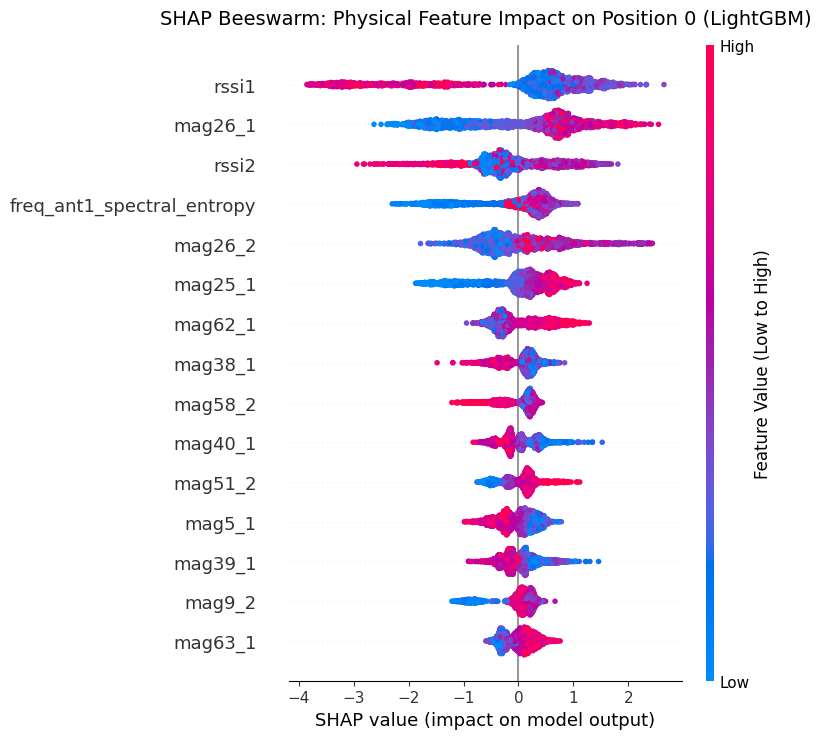

In [30]:
import shap
import pandas as pd
import matplotlib.pyplot as plt

shap.initjs()

if not isinstance(X_val_non_scaled, pd.DataFrame):
    feature_names = X_train_non_scaled.columns 
    X_val_df = pd.DataFrame(X_val_non_scaled, columns=feature_names)
else:
    X_val_df = X_val_non_scaled

explainer_lgbm = shap.TreeExplainer(lgbm_model)
shap_values_lgbm = explainer_lgbm.shap_values(X_val_df)

CLASSE_OBJECTIU = 0

if isinstance(shap_values_lgbm, list):
    shap_values_class = shap_values_lgbm[CLASSE_OBJECTIU]
else:
    shap_values_class = shap_values_lgbm[:, :, CLASSE_OBJECTIU]

plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_values_class, 
    X_val_df, 
    plot_type="dot",
    max_display=15, 
    show=False,
    color_bar_label='Feature Value (Low to High)'
)

plt.title(f"SHAP Beeswarm: Physical Feature Impact on Position {CLASSE_OBJECTIU} (LightGBM)", fontsize=14, pad=15)
plt.tight_layout()
plt.savefig(f"shap_beeswarm_lgbm_pos{CLASSE_OBJECTIU}.png", dpi=300, bbox_inches='tight')
plt.show()

--- SHAP: MODELS D'ARBRES (No Escalat) ---
Calculant TreeExplainer per a XGBoost_DistancePenalise...


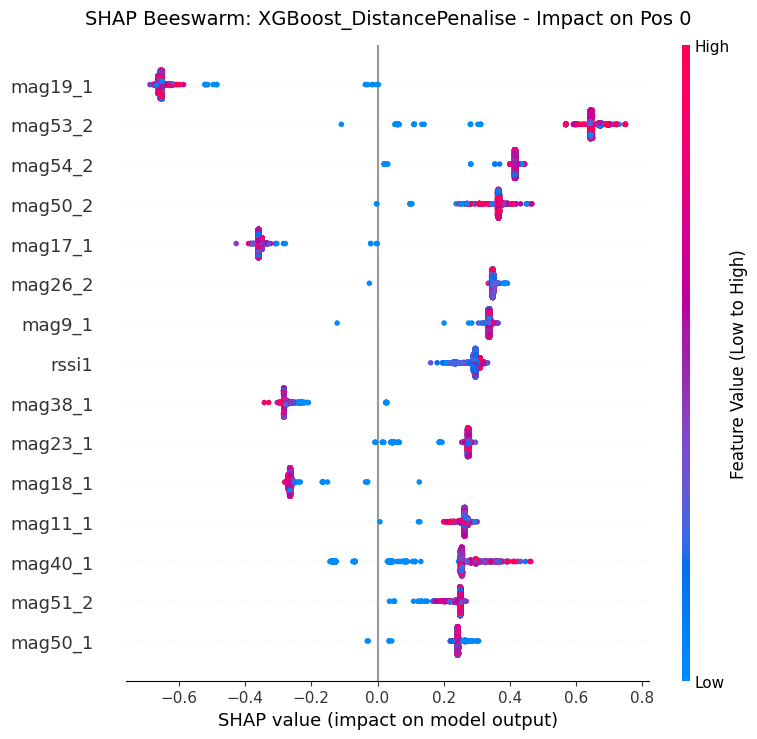

In [ ]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

shap.initjs()

if not isinstance(X_val_non_scaled, pd.DataFrame):
    feature_names = X_train_non_scaled.columns 
    X_val_tree_df = pd.DataFrame(X_val_non_scaled, columns=feature_names)
else:
    X_val_tree_df = X_val_non_scaled

CLASSE_OBJECTIU = 0
models_arbre = {
    "XGBoost_DistancePenalise": xgboost_distance_penalise
}

for nom, model in models_arbre.items():
    print(f"Calculant TreeExplainer per a {nom}...")
    explainer = shap.TreeExplainer(model)
    shap_vals = explainer.shap_values(X_val_tree_df)
    
    if isinstance(shap_vals, list):
        shap_vals_class = shap_vals[CLASSE_OBJECTIU]
    elif len(shap_vals.shape) == 3:
        if shap_vals.shape[1] == 10:
            shap_vals_class = shap_vals[:, CLASSE_OBJECTIU, :]
        else:
            shap_vals_class = shap_vals[:, :, CLASSE_OBJECTIU]
    else:
        shap_vals_class = shap_vals

    plt.figure(figsize=(10, 8))
    shap.summary_plot(
        shap_vals_class, 
        X_val_tree_df, 
        plot_type="dot", 
        max_display=15, 
        show=False,
        color_bar_label='Feature Value (Low to High)'
    )
    plt.title(f"SHAP Beeswarm: {nom} - Impact on Pos {CLASSE_OBJECTIU}", fontsize=14, pad=15)
    plt.tight_layout()
    plt.savefig(f"shap_beeswarm_{nom}.png", dpi=300, bbox_inches='tight')
    plt.show()